# 03 — Custo, latência e eficiência da ferramenta

Análise da dimensão **econômica e operacional**. Estes campos só estão disponíveis para
os 9 modelos da ferramenta (1350 linhas) — os chats comerciais não expõem custo/latência
e aparecem com `nao pertinente`, portanto este notebook usa **apenas `origem_resultado == 'ferramenta'`**.

Campos analisados:
- `custo_estimado_usd` — custo unitário da resposta (já considera tokens de entrada + saída)
- `latencia_s` — tempo total da resposta ao usuário
- `n_invocacoes` — número de chamadas ao LLM dentro do loop agentic (planejamento + execução)
- `input_tokens`, `output_tokens` — para entender o que dirige o custo

Perguntas guia:
1. Qual a faixa de custo por resposta entre os modelos?
2. Custo mais alto entrega correção melhor?
3. Quantas invocações o loop precisa? Modelos "melhores" usam menos chamadas?
4. **Qual o custo de responder corretamente uma pergunta?** (custo/acerto)
5. Pareto: existem modelos dominados (mais caros e piores)?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}

def detecta_artefatos():
    candidatos = [Path('../artefatos'), Path('../../artefatos'), Path('artefatos'),
                  Path('../'), Path('.')]
    for c in candidatos:
        if (c / 'result_unificado_final.xlsx').exists():
            return c.resolve()
    raise FileNotFoundError('result_unificado_final.xlsx não encontrado.')
ART = detecta_artefatos()

def infere_provedor(modelo: str) -> str:
    m = modelo.lower()
    if 'claude' in m: return 'anthropic'
    if 'gpt' in m or 'chatgpt' in m: return 'openai'
    if 'deepseek' in m: return 'deepseek'
    return 'desconhecido'

df_all = pd.read_excel(ART / 'result_unificado_final.xlsx')
df_all['provedor'] = df_all['modelo'].apply(infere_provedor)
for col in ['input_tokens','output_tokens','custo_estimado_usd','n_invocacoes','latencia_s']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# Apenas ferramenta
df = df_all[df_all['origem_resultado'] == 'ferramenta'].copy()
print(f'Ferramenta: {len(df)} respostas, {df.modelo.nunique()} modelos')
print(f'\nCobertura dos campos de custo/latência: {df.custo_estimado_usd.notna().sum()}/{len(df)}')


Ferramenta: 1350 respostas, 9 modelos

Cobertura dos campos de custo/latência: 1350/1350


## 1. Visão geral por modelo: tabela mestre

Pivot agregado: custo, latência, invocações, tokens, correção e concisão lado a lado.


In [2]:
mestre = (df.groupby(['modelo','provedor']).agg(
    n=('id','count'),
    aval_final_med=('avaliacao_final','mean'),
    taxa_perfeita=('avaliacao_final', lambda x: (x==1.0).mean()),
    concisao_med=('concisao_score','mean'),
    input_tokens_med=('input_tokens','mean'),
    output_tokens_med=('output_tokens','mean'),
    custo_med_usd=('custo_estimado_usd','mean'),
    custo_total_usd=('custo_estimado_usd','sum'),
    latencia_p50_s=('latencia_s','median'),
    latencia_p95_s=('latencia_s', lambda x: x.quantile(0.95)),
    n_invocacoes_med=('n_invocacoes','mean'),
).reset_index())

# Custo por resposta correta (acerto = avaliacao_final==1)
acertos_e_custo = (df.assign(acerto=lambda x: (x.avaliacao_final==1).astype(int))
                   .groupby('modelo')
                   .agg(acertos=('acerto','sum'),
                        custo_total=('custo_estimado_usd','sum')))
mestre = mestre.merge(
    acertos_e_custo.assign(custo_por_acerto_usd=lambda x: x.custo_total/x.acertos)[['custo_por_acerto_usd']],
    left_on='modelo', right_index=True)

mestre = mestre.sort_values('custo_med_usd')
print(mestre.round(4).to_string(index=False))

print('\nFaixa de custo médio por resposta:')
print(f'  Mais barato : {mestre.iloc[0]["modelo"]:20s} ${mestre.iloc[0]["custo_med_usd"]:.5f}')
print(f'  Mais caro   : {mestre.iloc[-1]["modelo"]:20s} ${mestre.iloc[-1]["custo_med_usd"]:.5f}')
print(f'  Razão       : {mestre.iloc[-1]["custo_med_usd"]/mestre.iloc[0]["custo_med_usd"]:.0f}×')


           modelo  provedor   n  aval_final_med  taxa_perfeita  concisao_med  input_tokens_med  output_tokens_med  custo_med_usd  custo_total_usd  latencia_p50_s  latencia_p95_s  n_invocacoes_med  custo_por_acerto_usd
      gpt-4o-mini    openai 150          0.9100         0.8467        0.8867         8921.5333           182.7467         0.0014           0.2172           5.200          9.7345            2.2467                0.0017
deepseek-v4-flash  deepseek 150          0.9700         0.9400        0.5600        13289.3733           429.0067         0.0020           0.2971           7.505         17.6455            2.4067                0.0021
     gpt-5.4-mini    openai 150          0.9067         0.8400        0.9933         6998.4667           172.9267         0.0060           0.9041           2.665          5.1365            2.3533                0.0072
 claude-haiku-4-5 anthropic 150          0.9367         0.8800        0.5333        14928.0000           460.3733         0.0172

## 2. Distribuição do custo por resposta (escala log)

A distribuição é altamente assimétrica — uma minoria de respostas custa muito mais
que a mediana por causa de loops longos. Boxplot em log.


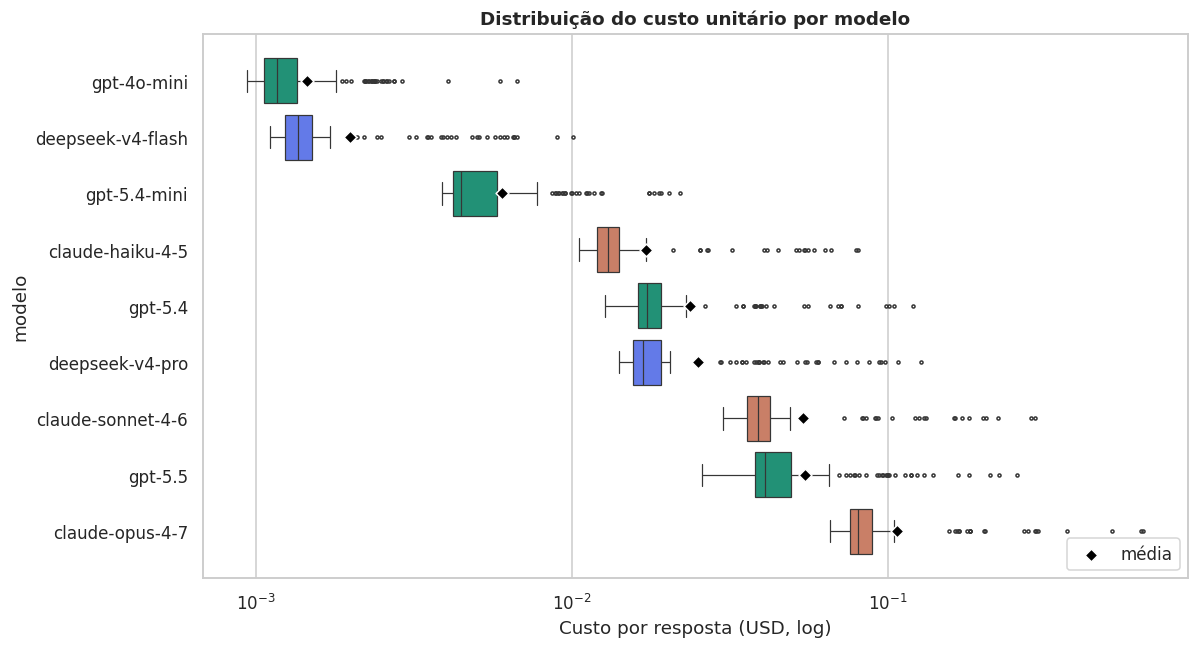

Custo TOTAL para responder os 150 questionários (3 editais × 50 perguntas):
  gpt-4o-mini            $  0.217
  deepseek-v4-flash      $  0.297
  gpt-5.4-mini           $  0.904
  claude-haiku-4-5       $  2.584
  gpt-5.4                $  3.540
  deepseek-v4-pro        $  3.751
  claude-sonnet-4-6      $  8.069
  gpt-5.5                $  8.210
  claude-opus-4-7        $ 16.044


In [3]:
ordem = mestre.sort_values('custo_med_usd')['modelo'].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
cores_box = [PALETA_PROVEDOR[infere_provedor(m)] for m in ordem]
sns.boxplot(data=df, y='modelo', x='custo_estimado_usd', order=ordem,
            hue='modelo', palette=dict(zip(ordem, cores_box)),
            legend=False, fliersize=2, linewidth=0.8, ax=ax)
ax.set_xscale('log')
ax.set_xlabel('Custo por resposta (USD, log)')
ax.set_title('Distribuição do custo unitário por modelo')

# Adicionar médias como ponto
for i, m in enumerate(ordem):
    med = df[df.modelo==m]['custo_estimado_usd'].mean()
    ax.scatter(med, i, marker='D', color='black', s=35, zorder=5, edgecolor='white')

ax.scatter([], [], marker='D', color='black', s=35, label='média', edgecolor='white')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

# Custo total para responder os 150 questões × 3 editais = 450 perguntas
print('Custo TOTAL para responder os 150 questionários (3 editais × 50 perguntas):')
total_por_modelo = df.groupby('modelo')['custo_estimado_usd'].sum().sort_values()
for m, v in total_por_modelo.items():
    print(f'  {m:22s} ${v:7.3f}')


## 3. Latência por modelo

Tempo de resposta percebido pelo usuário. p50, p95 e distribuição completa.


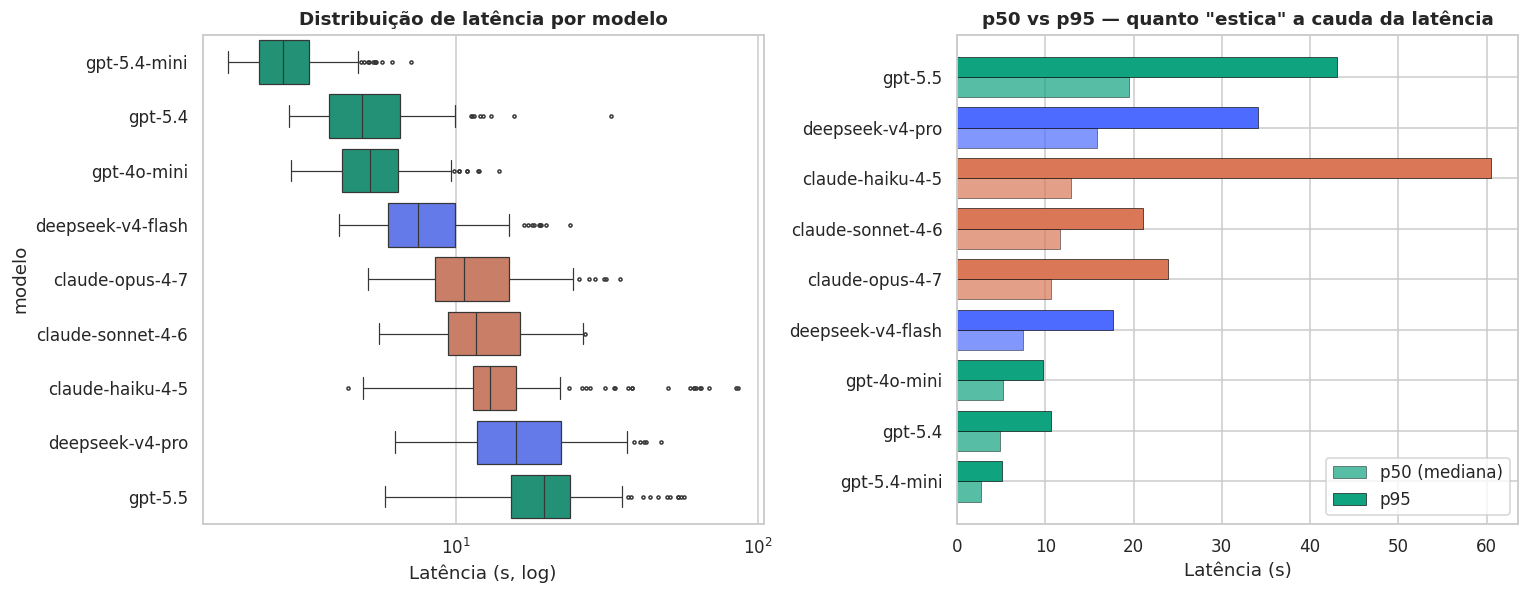

           modelo   p50   p95
     gpt-5.4-mini  2.66  5.14
          gpt-5.4  4.89 10.61
      gpt-4o-mini  5.20  9.73
deepseek-v4-flash  7.50 17.65
  claude-opus-4-7 10.62 23.90
claude-sonnet-4-6 11.68 21.09
 claude-haiku-4-5 12.96 60.53
  deepseek-v4-pro 15.85 34.06
          gpt-5.5 19.50 43.01


In [4]:
ordem_lat = df.groupby('modelo')['latencia_s'].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cores_box = [PALETA_PROVEDOR[infere_provedor(m)] for m in ordem_lat]
sns.boxplot(data=df, y='modelo', x='latencia_s', order=ordem_lat,
            hue='modelo', palette=dict(zip(ordem_lat, cores_box)),
            legend=False, fliersize=2, linewidth=0.8, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_xlabel('Latência (s, log)')
axes[0].set_title('Distribuição de latência por modelo')

# p50 vs p95 lado a lado
percentis = df.groupby('modelo')['latencia_s'].agg(
    p50='median', p95=lambda x: x.quantile(0.95)).reindex(ordem_lat).reset_index()
ys = np.arange(len(percentis))
w = 0.4
cores_p = [PALETA_PROVEDOR[infere_provedor(m)] for m in percentis['modelo']]
axes[1].barh(ys - w/2, percentis['p50'], w, color=cores_p, alpha=0.7,
             edgecolor='black', linewidth=0.4, label='p50 (mediana)')
axes[1].barh(ys + w/2, percentis['p95'], w, color=cores_p, alpha=1.0,
             edgecolor='black', linewidth=0.4, label='p95')
axes[1].set_yticks(ys); axes[1].set_yticklabels(percentis['modelo'])
axes[1].set_xlabel('Latência (s)')
axes[1].set_title('p50 vs p95 — quanto "estica" a cauda da latência')
axes[1].legend()
plt.tight_layout(); plt.show()

print(percentis.round(2).to_string(index=False))


## 4. Número de invocações no loop agentic

`n_invocacoes` é o número de chamadas ao LLM para responder uma única pergunta.
Inclui a chamada inicial mais qualquer retry/replanejamento. Mostra **eficiência
do loop**: modelos com bom planejamento devem precisar de menos invocações.


           modelo  inv_med  inv_p50  inv_p95  inv_max  aval  provedor
  claude-opus-4-7    2.240      2.0     4.00      7.0 0.977 anthropic
      gpt-4o-mini    2.247      2.0     3.00      5.0 0.910    openai
 claude-haiku-4-5    2.307      2.0     5.00      6.0 0.937 anthropic
          gpt-5.4    2.327      2.0     4.00      6.0 0.963    openai
claude-sonnet-4-6    2.333      2.0     5.00      7.0 0.973 anthropic
          gpt-5.5    2.347      2.0     4.00      6.0 0.997    openai
     gpt-5.4-mini    2.353      2.0     4.00      5.0 0.907    openai
deepseek-v4-flash    2.407      2.0     5.00      6.0 0.970  deepseek
  deepseek-v4-pro    2.407      2.0     4.55      6.0 0.963  deepseek


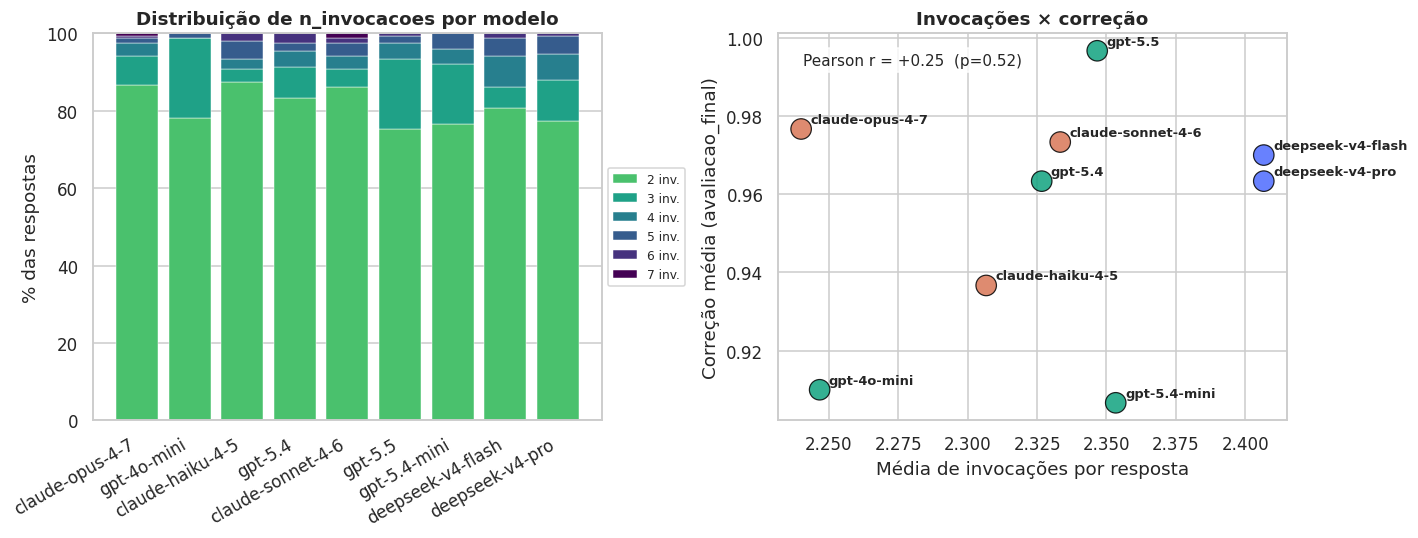

In [5]:
inv_summary = (df.groupby('modelo').agg(
    inv_med=('n_invocacoes','mean'),
    inv_p50=('n_invocacoes','median'),
    inv_p95=('n_invocacoes', lambda x: x.quantile(0.95)),
    inv_max=('n_invocacoes','max'),
    aval=('avaliacao_final','mean'),
    provedor=('provedor','first'),
).reset_index().sort_values('inv_med'))
print(inv_summary.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribuição de n_invocacoes
cnt = df.groupby(['modelo','n_invocacoes']).size().unstack(fill_value=0)
cnt_pct = cnt.div(cnt.sum(axis=1), axis=0) * 100
cnt_pct = cnt_pct.reindex(inv_summary['modelo'])

bottom = np.zeros(len(cnt_pct))
cmap = plt.cm.viridis_r
for col in sorted(cnt_pct.columns):
    cor = cmap(col/cnt_pct.columns.max())
    axes[0].bar(cnt_pct.index, cnt_pct[col], bottom=bottom, color=cor,
                edgecolor='white', linewidth=0.3, label=f'{int(col)} inv.')
    bottom += cnt_pct[col].values
axes[0].set_ylabel('% das respostas')
axes[0].set_title('Distribuição de n_invocacoes por modelo')
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# Scatter: invocações × correção
cores = [PALETA_PROVEDOR[p] for p in inv_summary['provedor']]
axes[1].scatter(inv_summary['inv_med'], inv_summary['aval'],
                c=cores, s=180, edgecolor='black', linewidth=0.8, alpha=0.85)
for _, r in inv_summary.iterrows():
    axes[1].annotate(r['modelo'], (r['inv_med'], r['aval']),
                     xytext=(6, 4), textcoords='offset points',
                     fontsize=8.5, fontweight='bold')
axes[1].set_xlabel('Média de invocações por resposta')
axes[1].set_ylabel('Correção média (avaliacao_final)')
axes[1].set_title('Invocações × correção')

r_inv, p_inv = stats.pearsonr(inv_summary['inv_med'], inv_summary['aval'])
axes[1].text(0.05, 0.95, f'Pearson r = {r_inv:+.2f}  (p={p_inv:.2f})',
             transform=axes[1].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout(); plt.show()


## 5. O que dirige o custo? Tokens de entrada vs saída

O custo de cada modelo depende de:
- preço do modelo (USD/M tokens)
- volume de tokens (entrada + saída)

Modelos com loop longo aumentam input_tokens (re-injetam contexto a cada invocação).


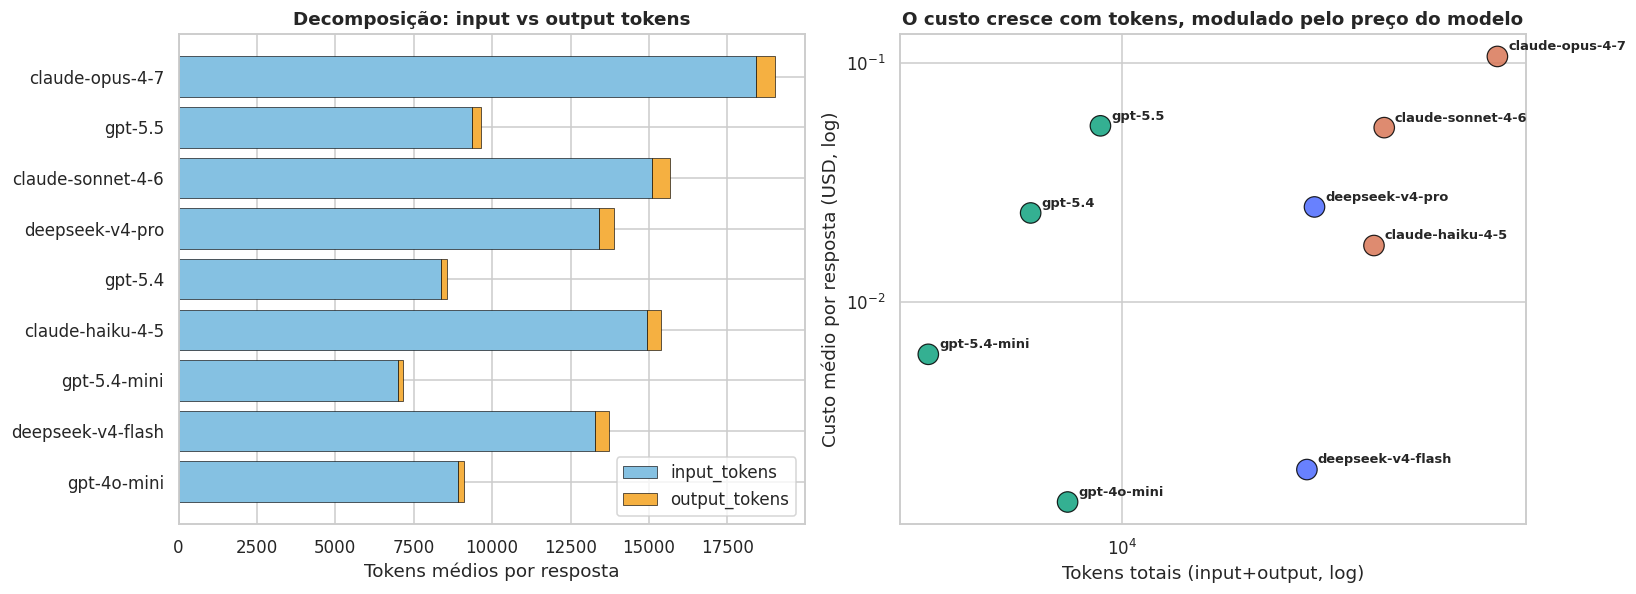

           modelo      input   output  custo  provedor
      gpt-4o-mini  8921.5333 182.7467 0.0014    openai
deepseek-v4-flash 13289.3733 429.0067 0.0020  deepseek
     gpt-5.4-mini  6998.4667 172.9267 0.0060    openai
 claude-haiku-4-5 14928.0000 460.3733 0.0172 anthropic
          gpt-5.4  8367.3867 178.5533 0.0236    openai
  deepseek-v4-pro 13422.0667 475.7467 0.0250  deepseek
claude-sonnet-4-6 15093.6000 567.3067 0.0538 anthropic
          gpt-5.5  9367.9533 263.0800 0.0547    openai
  claude-opus-4-7 18416.3800 595.1800 0.1070 anthropic


In [6]:
tok_cost = df.groupby('modelo').agg(
    input=('input_tokens','mean'),
    output=('output_tokens','mean'),
    custo=('custo_estimado_usd','mean'),
    provedor=('provedor','first'),
).reset_index().sort_values('custo')

# Decomposição: barras empilhadas mostrando input vs output
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ordem = tok_cost['modelo'].tolist()
ys = np.arange(len(ordem))
cores_p = [PALETA_PROVEDOR[p] for p in tok_cost['provedor']]
axes[0].barh(ys, tok_cost['input'], color='#85c1e2', edgecolor='black',
             linewidth=0.4, label='input_tokens')
axes[0].barh(ys, tok_cost['output'], left=tok_cost['input'],
             color='#f5b041', edgecolor='black', linewidth=0.4, label='output_tokens')
axes[0].set_yticks(ys); axes[0].set_yticklabels(ordem)
axes[0].set_xlabel('Tokens médios por resposta')
axes[0].set_title('Decomposição: input vs output tokens')
axes[0].legend()

# Scatter: log(input + output) × log(custo)
total_tok = tok_cost['input'] + tok_cost['output']
axes[1].scatter(total_tok, tok_cost['custo'], c=cores_p, s=180,
                edgecolor='black', linewidth=0.8, alpha=0.85)
for _, r in tok_cost.iterrows():
    axes[1].annotate(r['modelo'], (r['input']+r['output'], r['custo']),
                     xytext=(7, 4), textcoords='offset points',
                     fontsize=8.5, fontweight='bold')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Tokens totais (input+output, log)')
axes[1].set_ylabel('Custo médio por resposta (USD, log)')
axes[1].set_title('O custo cresce com tokens, modulado pelo preço do modelo')

plt.tight_layout(); plt.show()
print(tok_cost.round(4).to_string(index=False))


## 6. Pareto: correção × custo

**O gráfico que mais importa para defesa.** Plota custo no eixo X (log) e correção
no Y. Modelos abaixo-e-à-direita são dominados (mais caros sem ganhar correção).
A **fronteira de Pareto** liga os pontos não dominados.


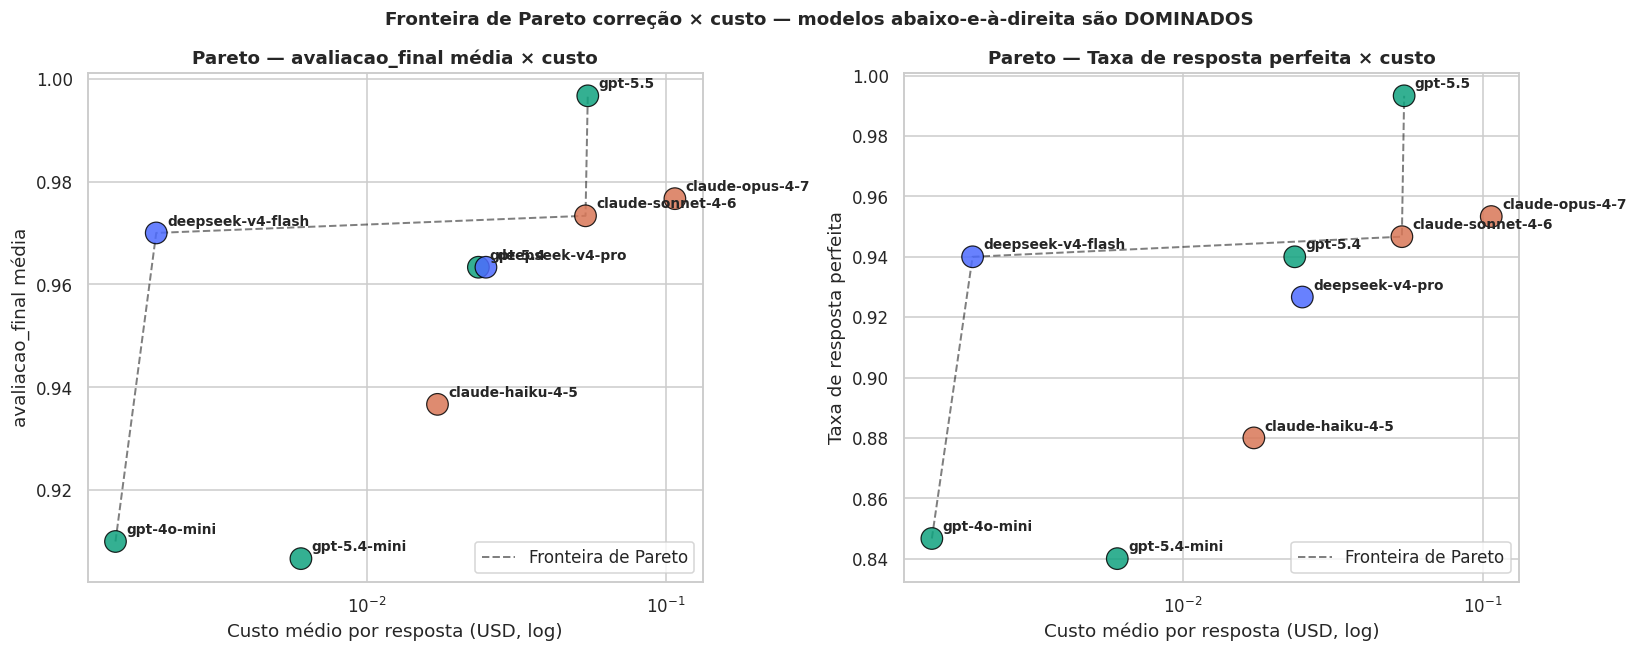


Modelos na fronteira de Pareto (avaliacao_final × custo):
  gpt-4o-mini             $0.00145  →  0.910
  deepseek-v4-flash       $0.00198  →  0.970
  claude-sonnet-4-6       $0.05379  →  0.973
  gpt-5.5                 $0.05473  →  0.997

Modelos dominados (Pareto-inferiores em avaliacao_final): ['gpt-5.4-mini', 'claude-haiku-4-5', 'gpt-5.4', 'deepseek-v4-pro', 'claude-opus-4-7']


In [7]:
def pareto_frontier(xs, ys, modelos):
    """Para minimização de x e maximização de y, devolve só os pontos não dominados."""
    pts = sorted(zip(xs, ys, modelos))  # ordenado por x crescente
    front = []
    best_y = -np.inf
    for x, y, m in pts:
        if y > best_y:
            front.append((x, y, m))
            best_y = y
    return front

pareto_df = mestre[['modelo','provedor','custo_med_usd','aval_final_med','taxa_perfeita','concisao_med']].copy()
front_corr = pareto_frontier(pareto_df['custo_med_usd'].values,
                              pareto_df['aval_final_med'].values,
                              pareto_df['modelo'].values)
front_perf = pareto_frontier(pareto_df['custo_med_usd'].values,
                              pareto_df['taxa_perfeita'].values,
                              pareto_df['modelo'].values)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, ycol, ylab, frontier in [
    (axes[0], 'aval_final_med',   'avaliacao_final média',   front_corr),
    (axes[1], 'taxa_perfeita',    'Taxa de resposta perfeita', front_perf),
]:
    cores = [PALETA_PROVEDOR[p] for p in pareto_df['provedor']]
    ax.scatter(pareto_df['custo_med_usd'], pareto_df[ycol],
               c=cores, s=200, edgecolor='black', linewidth=0.8, alpha=0.85, zorder=3)
    for _, r in pareto_df.iterrows():
        ax.annotate(r['modelo'], (r['custo_med_usd'], r[ycol]),
                    xytext=(7, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')
    # Fronteira
    fx = [p[0] for p in frontier]; fy = [p[1] for p in frontier]
    ax.plot(fx, fy, '--', color='black', alpha=0.5, linewidth=1.3, zorder=2,
            label='Fronteira de Pareto')

    ax.set_xscale('log')
    ax.set_xlabel('Custo médio por resposta (USD, log)')
    ax.set_ylabel(ylab)
    ax.set_title(f'Pareto — {ylab} × custo')
    ax.legend(loc='lower right')

plt.suptitle('Fronteira de Pareto correção × custo — modelos abaixo-e-à-direita são DOMINADOS',
             fontweight='bold')
plt.tight_layout(); plt.show()

print('\nModelos na fronteira de Pareto (avaliacao_final × custo):')
for x, y, m in front_corr:
    print(f'  {m:22s}  ${x:.5f}  →  {y:.3f}')

dominados = [m for m in pareto_df['modelo'] if m not in [p[2] for p in front_corr]]
print(f'\nModelos dominados (Pareto-inferiores em avaliacao_final): {dominados}')


## 7. Custo por resposta correta — métrica composta-chave

Esta é a métrica que o tomador de decisão olha: **$ que preciso gastar para ter
1 resposta perfeitamente correta?** Calculada como:
`custo_total ÷ número_de_acertos`.


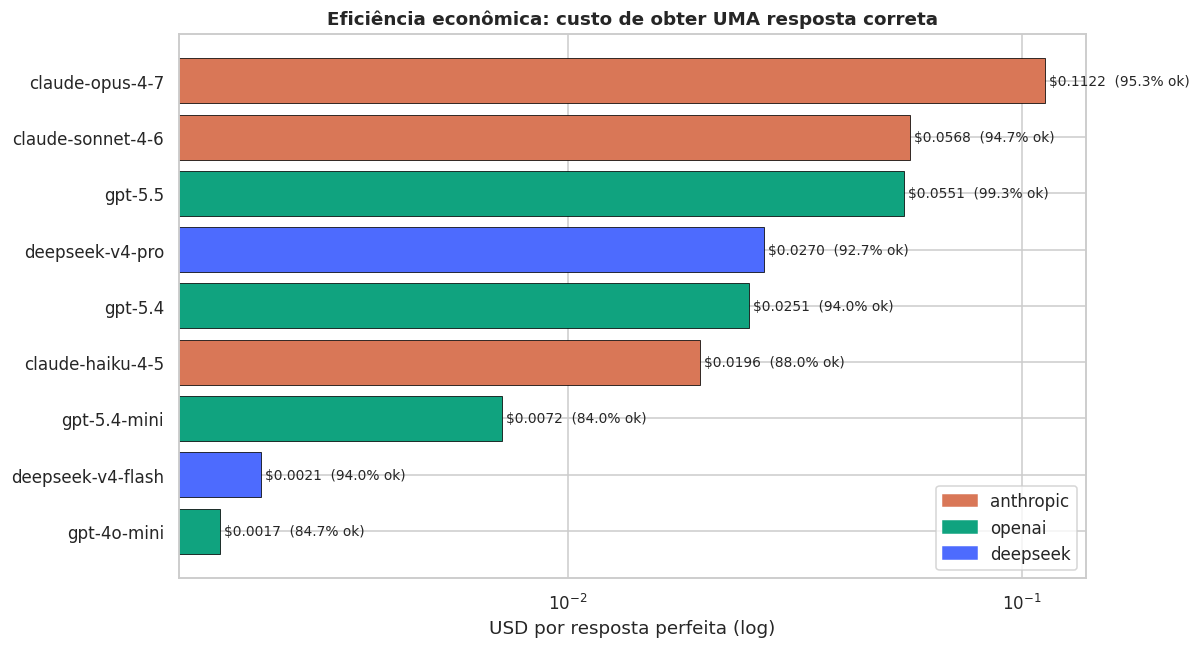


Modelo mais eficiente economicamente: gpt-4o-mini
  $/acerto = $0.00171, taxa_perfeita = 84.7%

Menos eficiente: claude-opus-4-7
  $/acerto = $0.11220, taxa_perfeita = 95.3%

Fator entre extremos: 66×


In [8]:
eff = mestre[['modelo','provedor','aval_final_med','taxa_perfeita',
              'custo_med_usd','custo_por_acerto_usd']].copy()
eff = eff.sort_values('custo_por_acerto_usd')

fig, ax = plt.subplots(figsize=(11, 6))
cores = [PALETA_PROVEDOR[p] for p in eff['provedor']]
bars = ax.barh(eff['modelo'], eff['custo_por_acerto_usd'],
               color=cores, edgecolor='black', linewidth=0.5)
for b, v, tx in zip(bars, eff['custo_por_acerto_usd'].values, eff['taxa_perfeita'].values):
    ax.text(v*1.02, b.get_y()+b.get_height()/2, f'${v:.4f}  ({tx:.1%} ok)',
            va='center', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('USD por resposta perfeita (log)')
ax.set_title('Eficiência econômica: custo de obter UMA resposta correta')

patches = [mpatches.Patch(color=c, label=p) for p,c in PALETA_PROVEDOR.items()]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout(); plt.show()

melhor = eff.iloc[0]
pior   = eff.iloc[-1]
print(f'\nModelo mais eficiente economicamente: {melhor["modelo"]}')
print(f'  $/acerto = ${melhor["custo_por_acerto_usd"]:.5f}, taxa_perfeita = {melhor["taxa_perfeita"]:.1%}')
print(f'\nMenos eficiente: {pior["modelo"]}')
print(f'  $/acerto = ${pior["custo_por_acerto_usd"]:.5f}, taxa_perfeita = {pior["taxa_perfeita"]:.1%}')
print(f'\nFator entre extremos: {pior["custo_por_acerto_usd"]/melhor["custo_por_acerto_usd"]:.0f}×')


## 8. Resumo

- A correção varia pouco entre modelos; o **custo varia em ordens de grandeza**
- O **custo por acerto** explicita esta diferença e separa de fato os modelos
- O loop agentic precisa de poucas invocações (≈ 2.2-2.4) em todos os modelos —
  então o custo é dominado pelo **preço do token**, não pelo número de chamadas
- Modelos da família Opus/Sonnet sentam acima da fronteira em correção mas
  são dominados em custo por opções mais baratas que praticamente igualam a qualidade
